<img src="images/arm_logo.png" width=250 alt="Project Pythia Logo"></img>

# BNF DSD C-Band Radar Relationships: R-Z, R-k, and R-A

---

## Overview
This notebook derives empirical power-law relationships between radar observables and rain rate (R)
using Drop Size Distribution (DSD) data from the ARM LDQUANTS and VDISQUANTS products at BNF sites M1 and S30.

Rainfall causes attenuation of radar signals, particularly at higher frequencies, and can also be used for
rainfall estimation. The LDQUANTS and VDISQUANTS are disdrometer-based ARM products that characterize DSD.
We want to derive optimized radar relationships over BNF for more accurate rainfall estimation compared to
using generalized or default relationships.

The three C-band relationships derived are:
1. **R-Z**: Rain rate (R) from reflectivity factor (Z), `R = a * Z^b` (Complete range)
2. **R-k**: Rain rate (R) from specific attenuation (k), `R = a * k^b` (Rainrate >= 1mm/hr)
3. **R-A**: Rain rate (R) from specific differential attenuation (A), `R = a * A^b` (Rainrate >= 0.1 mm/hr)

Coefficients are computed per instrument/site and mean relationship for all three sites/instruments:
M1 Laser Disdrometer (LD), M1 Video Disdrometer (VDIS), and S30 Laser Disdrometer (LD).

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Linear Regression](https://en.wikipedia.org/wiki/Linear_regression) | Necessary | |
| [Radar Reflectivity](https://training.weather.gov/nwstc/NEXRAD/RADAR/3-1.htm) | Necessary | |
| [Understanding of NetCDF](https://foundations.projectpythia.org/core/data-formats/netcdf-cf.html) | Helpful | Familiarity with metadata structure |

- **Time to learn**: 60 min.
- **System requirements**:
    - xarray, numpy, matplotlib, glob

---

## Imports

In [8]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

#### Load Datasets

A helper constructs the glob pattern from a base directory and datastream name, prints the file count, and returns an `xarray` dataset.

In [9]:
data_dir = '/gpfs/wolf2/arm/atm124/proj-shared/bnf/'

def load_dataset(data_dir, datastream):
    paths = sorted(glob.glob(f"{data_dir}{datastream}/{datastream}.*.nc"))
    print(f"{datastream}: {len(paths)} files")
    return xr.open_mfdataset(paths, combine='by_coords')

ds_ldqm1  = load_dataset(data_dir, 'bnfldquantsM1.c1')
ds_vdqm1  = load_dataset(data_dir, 'bnfvdisquantsM1.c1')
ds_ldqs30 = load_dataset(data_dir, 'bnfldquantsS30.c1')

rain_var = 'rain_rate' if 'rain_rate' in ds_ldqm1 else 'rainfall_rate'
print(f'\nRain rate variable: {rain_var}')

bnfldquantsM1.c1: 523 files
bnfvdisquantsM1.c1: 375 files
bnfldquantsS30.c1: 534 files

Rain rate variable: rain_rate


#### Power-Law Fitting Function

A single function handles all relationship types via log-log linear regression (`R = a · Y^b`), where Y is the radar variable (Z, k, or A).  
Set `is_dbz=True` for reflectivity to convert dBZ → linear Z units before fitting; k and A are already in linear units.

Per-relationship filtering criteria applied **before fitting**:
- **R-Z**: reflectivity filtered to **dBZ ≥ 0** (0 to max dBZ range); no rain rate threshold  
- **R-k**: only samples with **R ≥ 1 mm/hr** (KDP is unreliable in light rain)  
- **R-A**: only samples with **R > 0.1 mm/hr**

In [10]:
def fit_power_law(Y, R, is_dbz=False, rain_min=0.0):
    """Fit R = a * Y^b via log-log regression. Returns (a, b, N).

    Parameters
    ----------
    is_dbz   : convert Y from dBZ to linear Z before fitting; also enforces dBZ >= 0.
    rain_min : minimum rain rate (mm/hr) — samples below this threshold are excluded.
    """
    if is_dbz:
        Y_lin  = 10 ** (Y / 10)
        y_mask = Y_lin >= 1.0        # dBZ >= 0  →  linear Z >= 1
    else:
        Y_lin  = Y
        y_mask = Y_lin > 0

    valid = np.isfinite(Y_lin) & np.isfinite(R) & y_mask & (R >= rain_min) & (R > 0)
    Y_lin, R = Y_lin[valid], R[valid]
    b, log_a = np.polyfit(np.log10(Y_lin), np.log10(R), 1)
    return 10 ** log_a, b, len(Y_lin)

#### Compute R-Z, R-k, and R-A Relationships

Iterate over all sites and radar variables to fit each power-law (`R = a · Y^b`). Coefficients are stored in `df_results` once and reused for display and plotting — no redundant fitting calls downstream.

In [11]:
datasets = [
    ('M1 - LD Disdrometer',   ds_ldqm1),
    ('M1 - VDIS Disdrometer', ds_vdqm1),
    ('S30 - LD Disdrometer',  ds_ldqs30),
]

# Relationship label, variable name, is_dbz, rain_min (mm/hr)
#   R-Z : dBZ >= 0 enforced inside fit_power_law; no rain rate threshold
#   R-k : R >= 1 mm/hr  (KDP unreliable below light rain)
#   R-A : R > 0.1 mm/hr
radar_vars = [
    ('R-Z', 'reflectivity_factor_cband20c',               True,  0.0),
    ('R-k', 'specific_differential_phase_cband20c',       False, 1.0),
    ('R-A', 'specific_differential_attenuation_cband20c', False, 0.01),
]

records = []
for site_name, ds in datasets:
    R = ds[rain_var].values.astype(float)
    for rel, var, is_dbz, rain_min in radar_vars:
        y = ds[var].values.astype(float)
        a, b, n = fit_power_law(y, R, is_dbz=is_dbz, rain_min=rain_min)
        records.append({'Site': site_name, 'Relationship': rel, 'a': a, 'b': b, 'N': n})

df_results = pd.DataFrame(records)

#### Coefficient Summary Table

Print all fitted coefficients across sites and relationships.

In [12]:
print(df_results.to_string(index=False))

                 Site Relationship          a        b     N
  M1 - LD Disdrometer          R-Z   0.035419 0.640732 37295
  M1 - LD Disdrometer          R-k  20.563716 0.676618 18775
  M1 - LD Disdrometer          R-A 331.745723 0.596268 37467
M1 - VDIS Disdrometer          R-Z   0.026688 0.663554 24808
M1 - VDIS Disdrometer          R-k  19.455298 0.681032 10393
M1 - VDIS Disdrometer          R-A 378.634346 0.628594 24609
 S30 - LD Disdrometer          R-Z   0.033040 0.636505 34016
 S30 - LD Disdrometer          R-k  19.149218 0.678453 15516
 S30 - LD Disdrometer          R-A 283.675162 0.590253 33944


#### Scatter Plots with Fitted Power-Law Curves

One scatter plot per site per relationship, with radar variable on the x-axis and rain rate (R) on the y-axis.

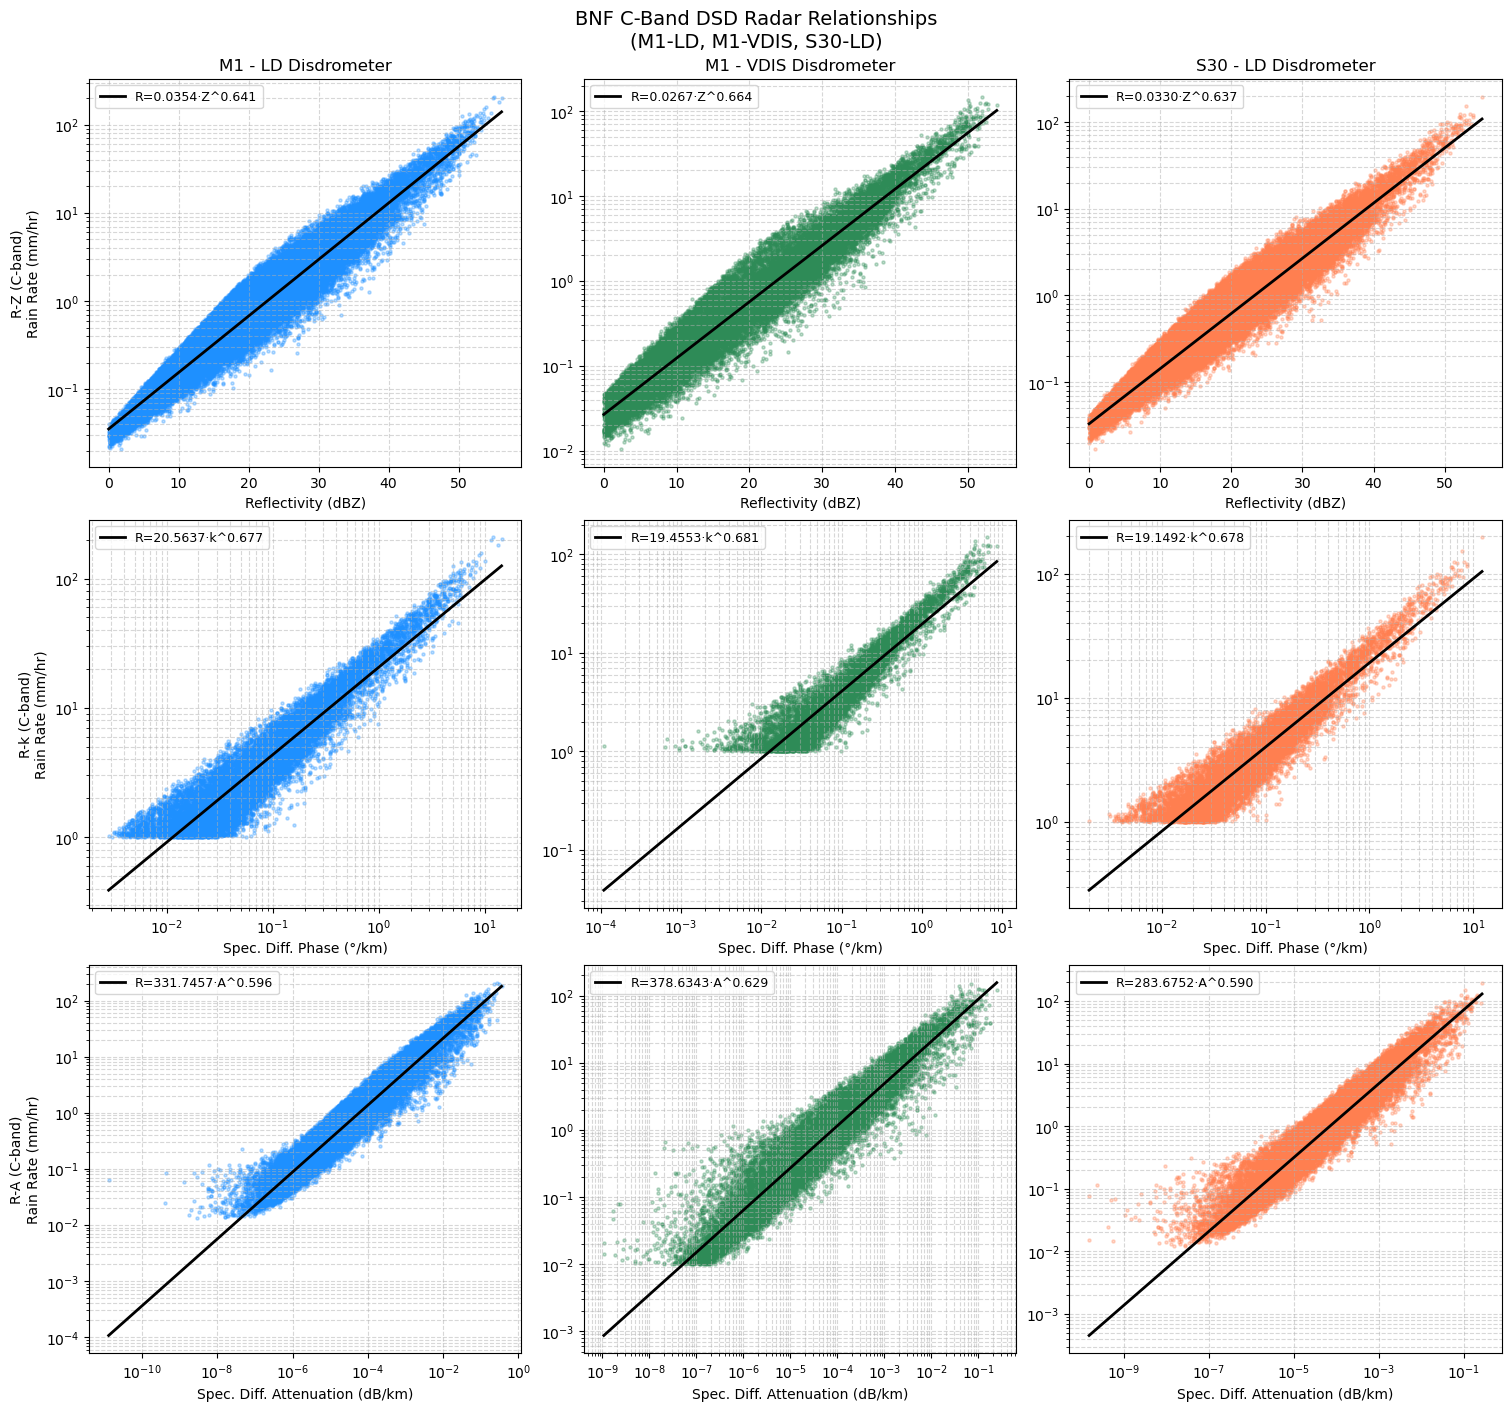

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(15, 14), constrained_layout=True)

colors       = ['dodgerblue', 'seagreen', 'coral']
display_info = {
    'R-Z': ('R-Z (C-band)',  'Reflectivity (dBZ)'),
    'R-k': ('R-k (C-band)',  'Spec. Diff. Phase (°/km)'),
    'R-A': ('R-A (C-band)',  'Spec. Diff. Attenuation (dB/km)'),
}

# Rain-rate thresholds per relationship (must match radar_vars)
rain_min_map = {'R-Z': 0.0, 'R-k': 1.0, 'R-A': 0.1}

# Build a lookup dict so the plot loop never re-calls fit_power_law
coeffs = {(r['Site'], r['Relationship']): (r['a'], r['b'])
          for _, r in df_results.iterrows()}

for col_idx, (site_name, ds) in enumerate(datasets):
    R_raw = ds[rain_var].values.astype(float)

    for row_idx, (rel, var, is_dbz, rain_min) in enumerate(radar_vars):
        ax    = axes[row_idx, col_idx]
        y_raw = ds[var].values.astype(float)
        a, b  = coeffs[(site_name, rel)]
        sym   = rel.split('-')[1]   # 'Z', 'k', or 'A'
        row_label, xlabel = display_info[rel]

        # Mirror the validity filter used in fit_power_law
        if is_dbz:
            y_lin  = 10 ** (y_raw / 10)
            y_mask = y_lin >= 1.0    # dBZ >= 0
        else:
            y_lin  = y_raw
            y_mask = y_lin > 0

        valid   = np.isfinite(R_raw) & np.isfinite(y_lin) & y_mask & (R_raw >= rain_min) & (R_raw > 0)
        R_v     = R_raw[valid]
        y_v     = y_raw[valid]      # original units for scatter (dBZ for Z)
        y_v_lin = y_lin[valid]      # linear units for fitting curve

        if is_dbz:
            # x-axis in dBZ; fit curve converts dBZ → linear Z for R = a·Z^b
            x_fit_dbz = np.linspace(y_v.min(), y_v.max(), 100)
            R_fit = a * (10 ** (x_fit_dbz / 10)) ** b
            ax.scatter(y_v, R_v, alpha=0.3, s=5, color=colors[col_idx])
            ax.plot(x_fit_dbz, R_fit, color='black', linewidth=2,
                    label=f'R={a:.4f}·{sym}^{b:.3f}')
        else:
            x_fit = np.logspace(np.log10(y_v_lin.min()), np.log10(y_v_lin.max()), 100)
            R_fit = a * x_fit ** b
            ax.scatter(y_v, R_v, alpha=0.3, s=5, color=colors[col_idx])
            ax.plot(x_fit, R_fit, color='black', linewidth=2,
                    label=f'R={a:.4f}·{sym}^{b:.3f}')
            ax.set_xscale('log')

        ax.set_yscale('log')
        ax.set_xlabel(xlabel)
        ax.legend(fontsize=9)
        ax.grid(True, which='both', ls='--', alpha=0.5)

        if row_idx == 0:
            ax.set_title(site_name)
        if col_idx == 0:
            ax.set_ylabel(f'{row_label}\nRain Rate (mm/hr)')

plt.suptitle('BNF C-Band DSD Radar Relationships\n(M1-LD, M1-VDIS, S30-LD)', fontsize=14)
plt.show()

#### Combined Coefficients — All Instruments and Sites

Pool data from all three instruments and sites into a single array to derive best-estimate power-law coefficients for each relationship. Append to `df_results` for a complete comparison table.

In [14]:
R_all = np.concatenate([ds[rain_var].values.astype(float) for _, ds in datasets])

combined_records = []
for rel, var, is_dbz, rain_min in radar_vars:
    y_all = np.concatenate([ds[var].values.astype(float) for _, ds in datasets])
    a, b, n = fit_power_law(y_all, R_all, is_dbz=is_dbz, rain_min=rain_min)
    combined_records.append({'Site': 'All Combined', 'Relationship': rel, 'a': a, 'b': b, 'N': n})

df_all = pd.concat([df_results, pd.DataFrame(combined_records)], ignore_index=True)
print(df_all.to_string(index=False))

                 Site Relationship          a        b     N
  M1 - LD Disdrometer          R-Z   0.035419 0.640732 37295
  M1 - LD Disdrometer          R-k  20.563716 0.676618 18775
  M1 - LD Disdrometer          R-A 331.745723 0.596268 37467
M1 - VDIS Disdrometer          R-Z   0.026688 0.663554 24808
M1 - VDIS Disdrometer          R-k  19.455298 0.681032 10393
M1 - VDIS Disdrometer          R-A 378.634346 0.628594 24609
 S30 - LD Disdrometer          R-Z   0.033040 0.636505 34016
 S30 - LD Disdrometer          R-k  19.149218 0.678453 15516
 S30 - LD Disdrometer          R-A 283.675162 0.590253 33944
         All Combined          R-Z   0.031705 0.647483 96119
         All Combined          R-k  19.833667 0.678858 44684
         All Combined          R-A 333.234228 0.605235 96020
